# Mobile Price Prediction — Multi-class Classification
**Course:** Introduction to Data Science (S2-25_DSECLZG532) — Assignment [Weightage 30%]

| | |
|---|---|
| **Group No.** | 10 |
| **Member** | Nitin Sahu (ID: 2025DC04103) |
| **Dataset** | Mobile Price Prediction (Train, Test) |

**Objective:** Build and evaluate multi-class classification models to predict the `price_range` (0 = low cost, 1 = medium, 2 = high, 3 = very high) of mobile phones from their technical specifications, and identify the best-performing model for deployment.

---
## 1. Import Libraries / Dataset [1M]
We import the core scientific Python stack: **numpy/pandas** for data handling, **matplotlib/seaborn** for visualization, and **scikit-learn** for preprocessing, modelling and evaluation. The dataset was provided as two CSV files (train with labels, test without labels).

In [ ]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: preprocessing, models, evaluation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                             precision_recall_fscore_support, ConfusionMatrixDisplay)
import joblib

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42
print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Load the training dataset and display the initial few records
train_df = pd.read_csv("Mobile_Price_Prediction_train.csv")
test_df  = pd.read_csv("Mobile_Price_Prediction_test.csv")

train_df.head()

,id,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,1,707,No,2.1,Yes,2,0,25,0.8,Med,3,17,495,574,3838,9,2,7,1,No,Yes,3
1,2,1218,No,1.8,Yes,1,1,14,0.5,Med,3,4,229,616,398,17,0,5,1,No,No,0
2,3,1986,No,0.5,No,7,0,51,0.4,Low,3,9,342,774,3165,5,0,13,1,No,No,3
3,4,1290,No,0.5,No,0,0,3,0.1,Med,6,4,600,1109,1214,9,8,15,0,Yes,Yes,1
4,5,1135,Yes,2.8,Yes,9,0,43,0.4,Med,1,11,690,1589,3204,18,13,6,1,No,No,3


In [3]:
# Verify the target column exists and holds the expected 4 classes
print("Target column present :", "price_range" in train_df.columns)
print("Target classes        :", sorted(train_df["price_range"].unique()))

Target column present : True
Target classes        : [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


**Verification:** The target column `price_range` is present in the training set and contains exactly the four expected classes `0, 1, 2, 3`, confirming this is a 4-class classification problem.

---
## 2. Data and Data Models [2M]
### 2.1 Shape, feature names and data types

In [4]:
print("Train shape:", train_df.shape, "| Test shape:", test_df.shape)

# Feature names + dtypes in one frame
pd.DataFrame({"dtype": train_df.dtypes.astype(str),
              "n_unique": train_df.nunique(),
              "example": train_df.iloc[0]})

Train shape: (2000, 22) | Test shape: (1000, 24)


,dtype,n_unique,example
id,int64,2000,1
battery_power,int64,1094,707
blue,str,2,No
clock_speed,float64,26,2.1
dual_sim,str,2,Yes
fc,int64,20,2
four_g,int64,2,0
int_memory,int64,63,25
m_dep,float64,10,0.8
mobile_wt,str,3,Med


### 2.2 Sanity check — 2 rows
We print two rows to visually confirm every feature is present and that the target value plausibly matches the specs (e.g., a phone with very high RAM should sit in a higher price band).

In [5]:
train_df.sample(2, random_state=RANDOM_STATE)

,id,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
1860,1861,1730,No,2.0,Yes,0,1,20,0.1,Med,4,10,418,1023,1595,14,0,12,1,Yes,No,1
353,354,802,No,0.5,Yes,3,0,43,0.6,Med,5,6,527,734,3063,17,13,4,0,Yes,No,2


**Sanity observations:** All 20 specification features (plus `id` and target) are present. Rows with high `ram` values correspond to higher `price_range`, and low-RAM rows to lower bands — the target is consistent with the features. Note that `blue`, `dual_sim`, `touch_screen`, `wifi` are stored as Yes/No text and `mobile_wt` as Low/Med/High text — these will require encoding.

### 2.3 Data pipeline design
The end-to-end data pipeline for this project has the following stages:

1. **Data extraction** — obtaining the raw data from its source; here the provided CSV exports (in production this could be a database, API or data lake query).
2. **Data ingestion** — reading the extracted files into the working environment (`pd.read_csv`) so they become analyzable DataFrames.
3. **Data cleaning** — removing structural defects: the test CSV contains three empty `Unnamed` columns from trailing commas; we also check for nulls and duplicates.
4. **Data exploration** — profiling the data with summary statistics and visualizations (Section 3) to understand distributions, class balance and relationships.
5. **Data wrangling** — reshaping/correcting values into a consistent, model-ready form, e.g., converting Yes/No text flags to 1/0 and ordinal text (`Low/Med/High`) to ordered integers.
6. **Data versioning** — keeping raw and processed datasets distinct (we never mutate the raw DataFrames in place; cleaned copies are created), so every experiment is reproducible; tools like DVC or Git-LFS do this at scale.
7. **Data transformation** — applying mathematical transforms required by the models, here standardization (zero mean, unit variance) fitted on training data only.
8. **Feature management** — selecting and tracking which features feed the model, ranking them by importance (RF importances + mutual information), and persisting the final feature list with the model so serving uses the identical schema.

---
## 3. Data Visualization and Exploration [6M]
### 3.1 Class balance

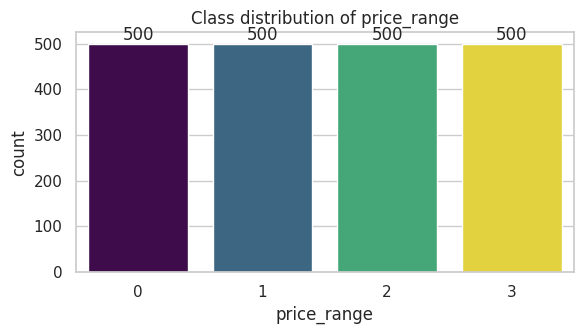

In [6]:
fig, ax = plt.subplots(figsize=(6, 3.5))
sns.countplot(x="price_range", data=train_df, hue="price_range", palette="viridis", legend=False, ax=ax)
ax.set_title("Class distribution of price_range")
for c in ax.containers: ax.bar_label(c)
plt.tight_layout(); plt.show()

**Comment on class imbalance:** Each of the four classes has exactly **500 samples (25%)** — the dataset is *perfectly balanced*. Therefore no resampling (SMOTE/undersampling) is required, accuracy is a meaningful headline metric, and macro-averaged metrics will agree closely with weighted averages.

### 3.2 Statistical description (summary measures, one frame)

In [7]:
# Full statistical description of all numeric attributes in a single frame
train_df.drop(columns=["id"]).describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
battery_power,2000.0,1238.52,439.42,501.0,851.75,1226.0,1615.25,1998.0
clock_speed,2000.0,1.52,0.82,0.5,0.70,1.5,2.20,3.0
fc,2000.0,4.31,4.34,0.0,1.00,3.0,7.00,19.0
four_g,2000.0,0.52,0.50,0.0,0.00,1.0,1.00,1.0
int_memory,2000.0,32.05,18.15,2.0,16.00,32.0,48.00,64.0
m_dep,2000.0,0.50,0.29,0.1,0.20,0.5,0.80,1.0
n_cores,2000.0,4.52,2.29,1.0,3.00,4.0,7.00,8.0
pc,2000.0,9.92,6.06,0.0,5.00,10.0,15.00,20.0
px_height,2000.0,645.11,443.78,0.0,282.75,564.0,947.25,1960.0
px_width,2000.0,1251.52,432.20,500.0,874.75,1247.0,1633.00,1998.0


**Key summary observations:**
- `ram` spans ~256–3998 MB, `battery_power` ~500–1998 mAh — wide, roughly uniform ranges.
- `fc` (front camera) and `px_height` have minimum 0 — plausible (no front camera / entry-level rounding) but `sc_w = 0` cm is physically impossible and is treated as a data-quality issue in Section 4.
- Feature scales differ by orders of magnitude (e.g., `m_dep` ≤ 1 vs `ram` ≈ 4000), motivating standardization for scale-sensitive models such as SVM.

### 3.3 Univariate analysis — histograms and countplots

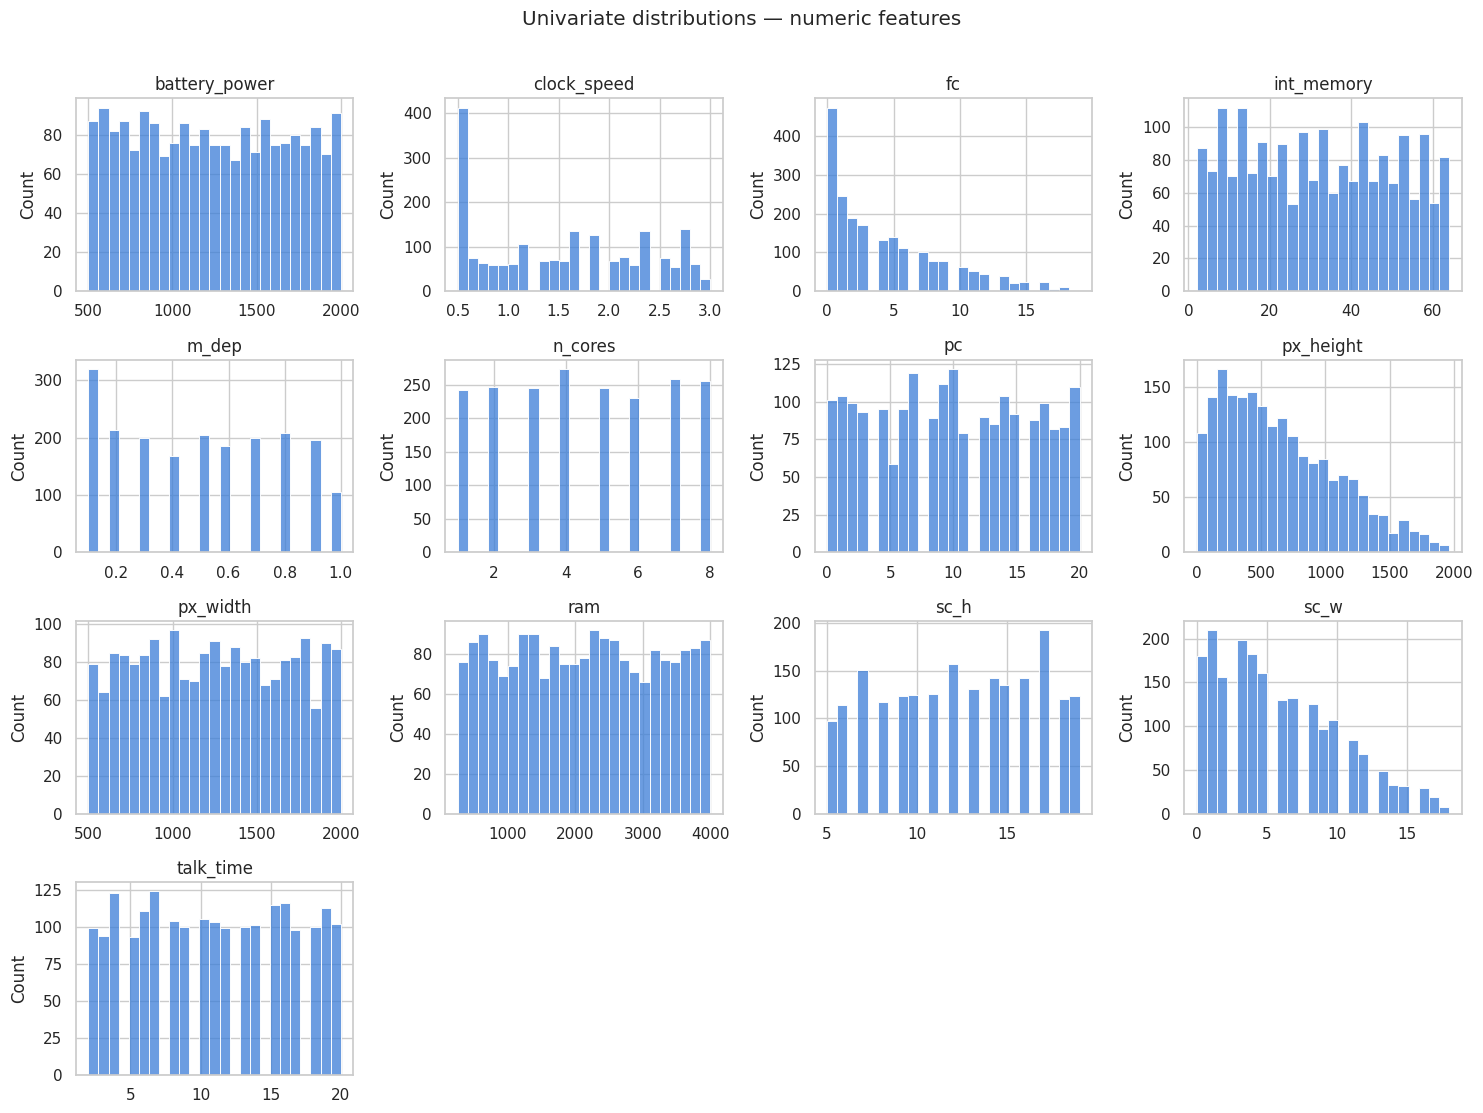

In [8]:
num_cols = ["battery_power","clock_speed","fc","int_memory","m_dep","n_cores",
            "pc","px_height","px_width","ram","sc_h","sc_w","talk_time"]
fig, axes = plt.subplots(4, 4, figsize=(15, 11))
for ax, col in zip(axes.flat, num_cols):
    sns.histplot(train_df[col], bins=25, ax=ax, color="#3b7dd8")
    ax.set_title(col); ax.set_xlabel("")
for ax in axes.flat[len(num_cols):]: ax.axis("off")
fig.suptitle("Univariate distributions — numeric features", y=1.01)
plt.tight_layout(); plt.show()

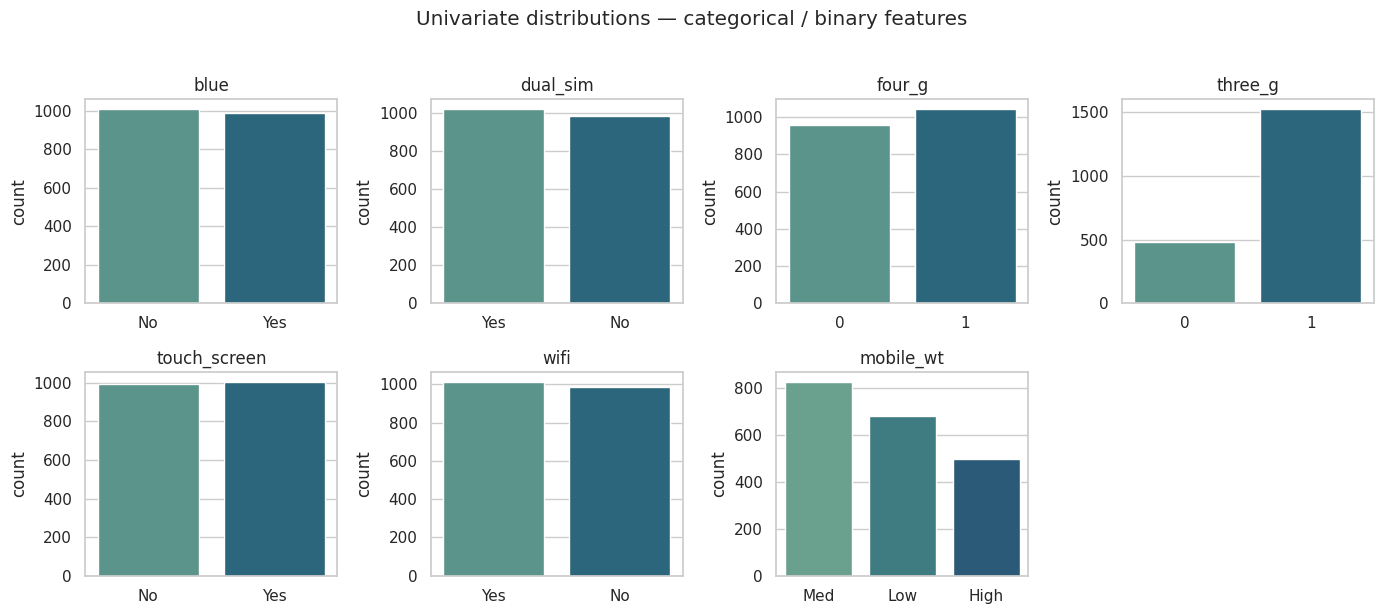

In [9]:
cat_cols = ["blue","dual_sim","four_g","three_g","touch_screen","wifi","mobile_wt"]
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for ax, col in zip(axes.flat, cat_cols):
    sns.countplot(x=col, data=train_df, hue=col, palette="crest", legend=False, ax=ax)
    ax.set_title(col); ax.set_xlabel("")
axes.flat[-1].axis("off")
fig.suptitle("Univariate distributions — categorical / binary features", y=1.02)
plt.tight_layout(); plt.show()

**Univariate observations:** Most numeric features are close to **uniform** (typical of synthetic spec data); `fc`, `px_height` and `sc_w` are **right-skewed**. Binary features are roughly 50/50 except `three_g` (~76% support it), and `mobile_wt` categories are fairly even.

### 3.4 Bivariate analysis — boxplots, scatterplots, correlation heatmap

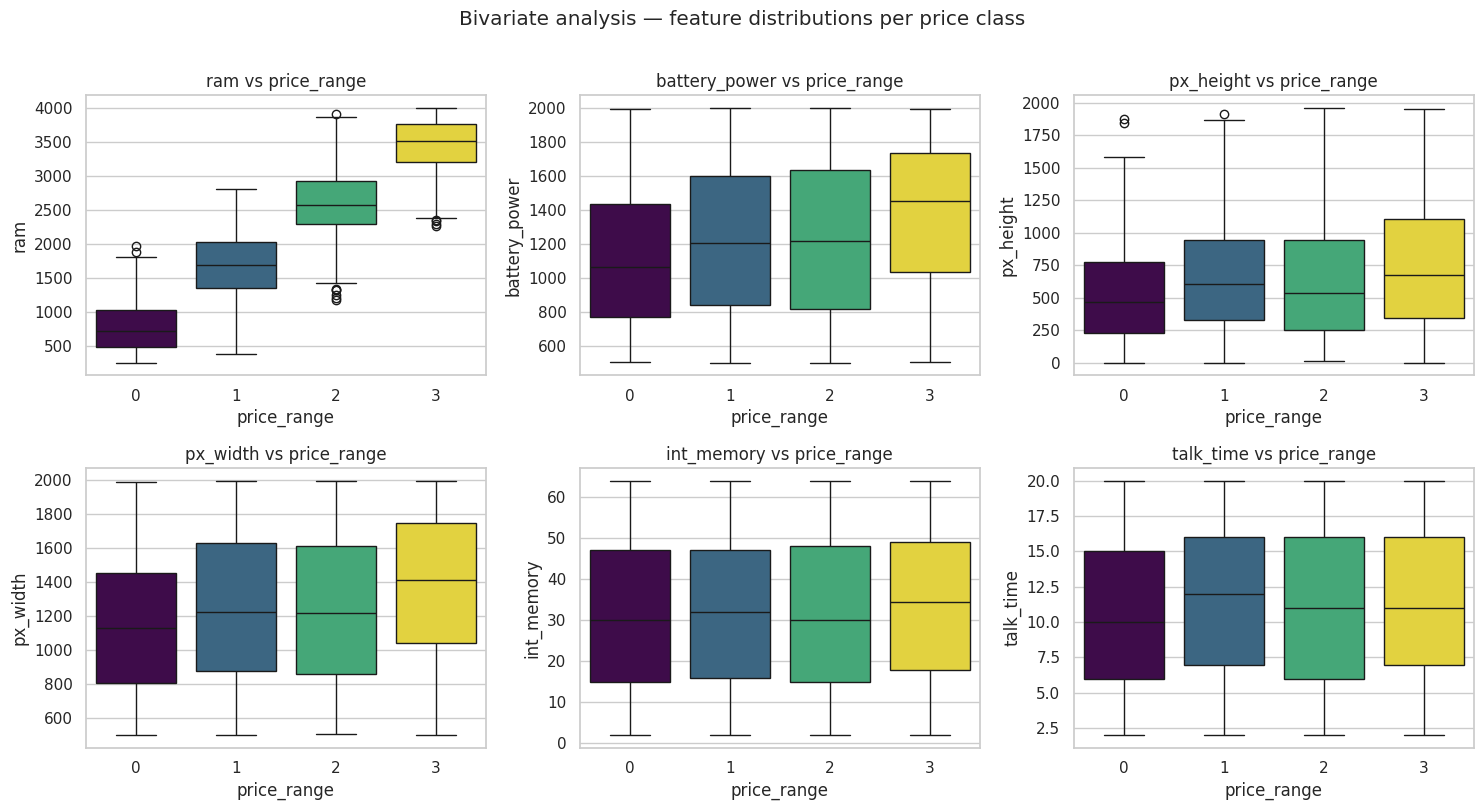

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, ["ram","battery_power","px_height","px_width","int_memory","talk_time"]):
    sns.boxplot(x="price_range", y=col, data=train_df, hue="price_range",
                palette="viridis", legend=False, ax=ax)
    ax.set_title(f"{col} vs price_range")
fig.suptitle("Bivariate analysis — feature distributions per price class", y=1.01)
plt.tight_layout(); plt.show()

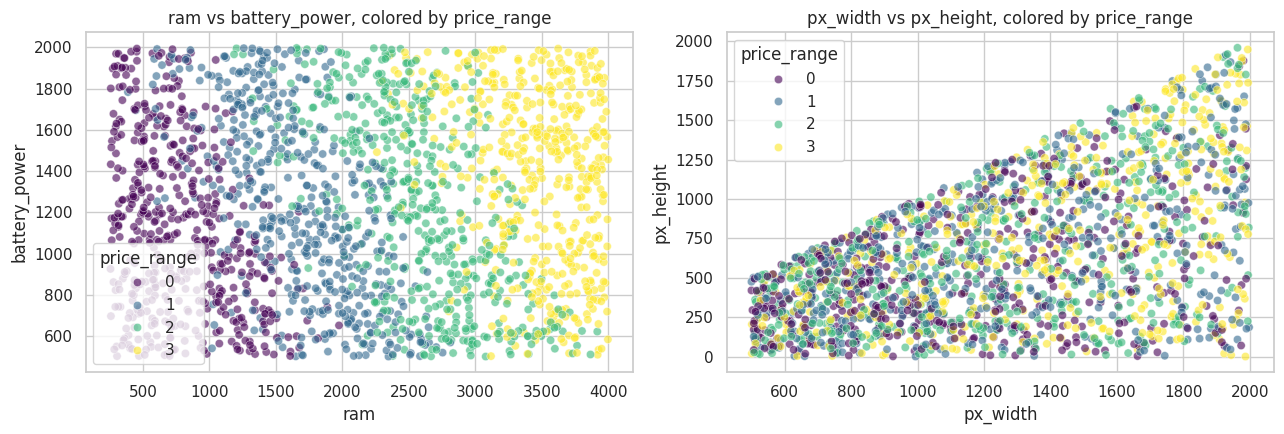

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.scatterplot(x="ram", y="battery_power", hue="price_range", data=train_df,
                palette="viridis", alpha=0.6, ax=axes[0])
axes[0].set_title("ram vs battery_power, colored by price_range")
sns.scatterplot(x="px_width", y="px_height", hue="price_range", data=train_df,
                palette="viridis", alpha=0.6, ax=axes[1])
axes[1].set_title("px_width vs px_height, colored by price_range")
plt.tight_layout(); plt.show()

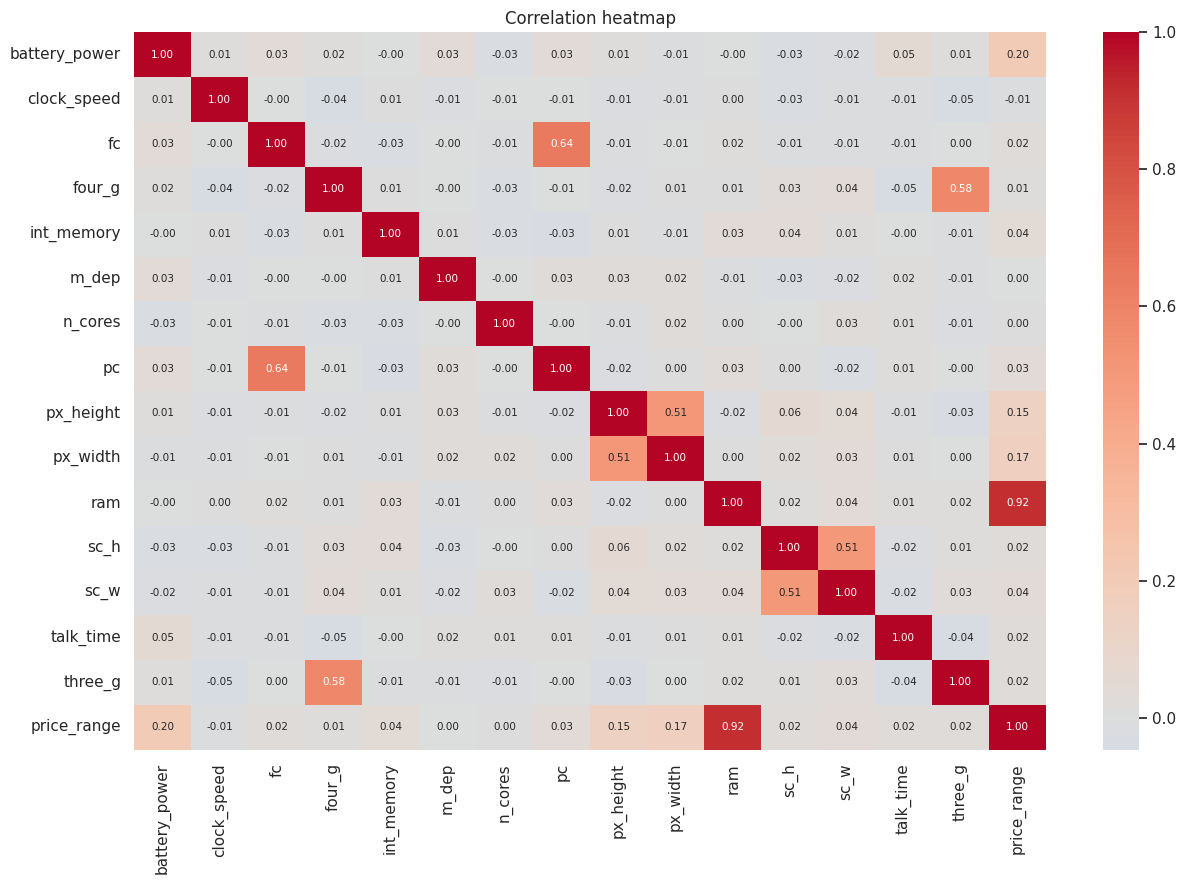

In [12]:
# Correlation heatmap (numeric features + target)
corr = train_df.drop(columns=["id","blue","dual_sim","touch_screen","wifi","mobile_wt"]).corr()
plt.figure(figsize=(13, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            annot_kws={"size": 7.5})
plt.title("Correlation heatmap")
plt.tight_layout(); plt.show()

### 3.5 Observations — influential features and nonlinear patterns
- **Most influential feature by far: `ram`** (correlation ≈ 0.92 with `price_range`). The boxplot shows almost non-overlapping RAM ranges per class, and the RAM scatterplot shows clean horizontal class bands.
- **Secondary influences:** `battery_power`, `px_height`, `px_width` each show a mild positive relationship with price (corr ≈ 0.15–0.20) — visible as gently rising medians in the boxplots.
- **Weak/irrelevant features:** connectivity flags (`blue`, `wifi`, `dual_sim`, `touch_screen`), `clock_speed`, `n_cores`, `talk_time` show near-zero correlation with the target.
- **Nonlinear patterns:** the `ram → price_range` relationship is a **step function** (thresholded bands), not a smooth line — tree-based models capture such thresholds naturally. `px_height`/`px_width` interact multiplicatively (their product ≈ resolution is what matters), another nonlinearity. `fc`–`pc` (0.64) and `sc_w`–`sc_h` (0.51) are correlated feature *pairs* (front/primary camera, screen dimensions), and `three_g`–`four_g` are logically dependent (4G implies 3G).

---
## 4. Data Pre-processing and Cleaning [5M]
### 4.1 Missing values, duplicates, structural cleaning

In [13]:
print("Nulls in train:", int(train_df.isnull().sum().sum()),
      "| Duplicate rows in train:", int(train_df.duplicated().sum()))
print("Test columns with nulls:")
print(test_df.isnull().sum()[test_df.isnull().sum() > 0])

Nulls in train: 0 | Duplicate rows in train: 0
Test columns with nulls:
Unnamed: 21    1000
Unnamed: 22     999
Unnamed: 23    1000
dtype: int64


In [14]:
# Structural cleaning: the test CSV carries 3 empty 'Unnamed' columns (trailing commas).
# We drop them; raw frames are kept intact and we work on cleaned copies (data versioning).
train_clean = train_df.copy()
test_clean  = test_df.drop(columns=[c for c in test_df.columns if c.startswith("Unnamed")]).copy()
print("Cleaned test shape:", test_clean.shape)

Cleaned test shape: (1000, 21)


### 4.2 Outliers and skewness

In [15]:
# IQR-based outlier count per numeric feature
q1, q3 = train_clean[num_cols].quantile(0.25), train_clean[num_cols].quantile(0.75)
iqr = q3 - q1
outliers = ((train_clean[num_cols] < q1 - 1.5*iqr) | (train_clean[num_cols] > q3 + 1.5*iqr)).sum()

pd.DataFrame({"IQR_outliers": outliers,
              "skewness": train_clean[num_cols].skew().round(2)}).T

,battery_power,clock_speed,fc,int_memory,m_dep,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time
IQR_outliers,0.00,0.00,18.00,0.00,0.00,0.0,0.00,2.00,0.00,0.00,0.0,0.00,0.00
skewness,0.03,0.18,1.02,0.06,0.09,0.0,0.02,0.67,0.01,0.01,-0.1,0.63,0.01


In [16]:
# 'sc_w' = 0 cm is physically impossible -> treat as missing and impute with the median
zero_sc_w = (train_clean["sc_w"] == 0).sum()
med = train_clean.loc[train_clean["sc_w"] > 0, "sc_w"].median()
train_clean["sc_w"] = train_clean["sc_w"].replace(0, med)
test_clean["sc_w"]  = test_clean["sc_w"].replace(0, med)
print(f"Replaced {zero_sc_w} impossible sc_w=0 values with median = {med}")

Replaced 180 impossible sc_w=0 values with median = 6.0


**Pre-processing decisions (with justification):**
- **No missing values / duplicates** in the training data → no imputation or deduplication needed there.
- **Structural fix:** dropped the three all-empty `Unnamed` columns from the test file (CSV artifact).
- **Outliers:** only `fc` and `px_height` show mild IQR "outliers", but these are *valid spec values* (many phones lack a front camera), not measurement errors — capping/removing them would discard genuine signal, so they are retained. Tree models are insensitive to outliers anyway.
- **Impossible values:** `sc_w = 0` cm cannot occur physically, so it was treated as a disguised missing value and median-imputed (the same constant applied to the test set to avoid leakage of test statistics).
- **Skewness:** mild (|skew| < 1.1 everywhere); no log/power transform is required, especially since our main models (trees) are monotone-transform invariant.

### 4.3 Encoding categorical variables

In [17]:
# Label Encoding for binary Yes/No flags (equivalent to LabelEncoder, mapping made explicit
# so train/test are guaranteed to be encoded identically)
binary_map  = {"Yes": 1, "No": 0}
ordinal_map = {"Low": 0, "Med": 1, "High": 2}   # mobile_wt has a natural order -> ordinal encoding

for df_ in (train_clean, test_clean):
    for col in ["blue", "dual_sim", "touch_screen", "wifi"]:
        df_[col] = df_[col].map(binary_map)
    df_["mobile_wt"] = df_["mobile_wt"].map(ordinal_map)

train_clean[["blue","dual_sim","touch_screen","wifi","mobile_wt"]].head(3)

,blue,dual_sim,touch_screen,wifi,mobile_wt
0,0,1,0,1,1
1,0,1,0,0,1
2,0,0,0,0,0


**Encoding justification:** `blue`, `dual_sim`, `touch_screen`, `wifi` are binary, so label encoding to {0,1} is lossless and adds no columns. `mobile_wt` (Low < Med < High) is **ordinal**, so ordered-integer encoding preserves its ranking; One-Hot encoding was *not* used here because it would destroy the order information and inflate dimensionality — One-Hot is the right tool only for *nominal* multi-category variables, of which this dataset has none.

### 4.4 Data balancing
The countplot in §3.1 showed a perfectly balanced target (500/class). Modern balancing techniques — **SMOTE** (synthetic minority oversampling), **ADASYN** (density-adaptive SMOTE), **SMOTE-Tomek/SMOTE-ENN** hybrids, and cost-sensitive `class_weight` schemes — exist to stop models from ignoring minority classes; on imbalanced data they typically raise minority-class recall and macro-F1 at a small cost to overall accuracy. **Applied to already-balanced data they add nothing and can inject synthetic noise**, so we deliberately do not resample. As a safeguard, `class_weight="balanced"` would be a zero-cost option for the SVM/tree models, but with equal priors it reduces to uniform weights.

### 4.5 Feature transformation — standardization

In [18]:
feature_cols = [c for c in train_clean.columns if c not in ("id", "price_range")]

X_raw = train_clean[feature_cols]
y     = train_clean["price_range"]

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_raw), columns=feature_cols)  # fit on TRAIN only
X_test_scaled = pd.DataFrame(scaler.transform(test_clean[feature_cols]), columns=feature_cols)

X_scaled.describe().loc[["mean","std"]].round(2).iloc[:, :8]

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep
mean,0.0,-0.0,0.0,0.0,0.0,0.0,-0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


**Transformation justification:** **Standardization** (z-score) was chosen because feature scales differ by up to 4 orders of magnitude (`m_dep` ≈ 0–1 vs `ram` ≈ 256–3998). **SVM is distance/margin-based and would otherwise be dominated by `ram` and `battery_power` alone.** Standardization (rather than Min-Max normalization) is preferred because it does not squash information when future data exceeds the training min/max, and features here have no hard natural bounds. Tree-based models are scale-invariant, so scaling neither helps nor harms them — using one scaled representation keeps the pipeline simple and consistent. The scaler is **fitted on the training set only** and re-used to transform the test set, preventing data leakage.

### 4.6 Feature importance techniques

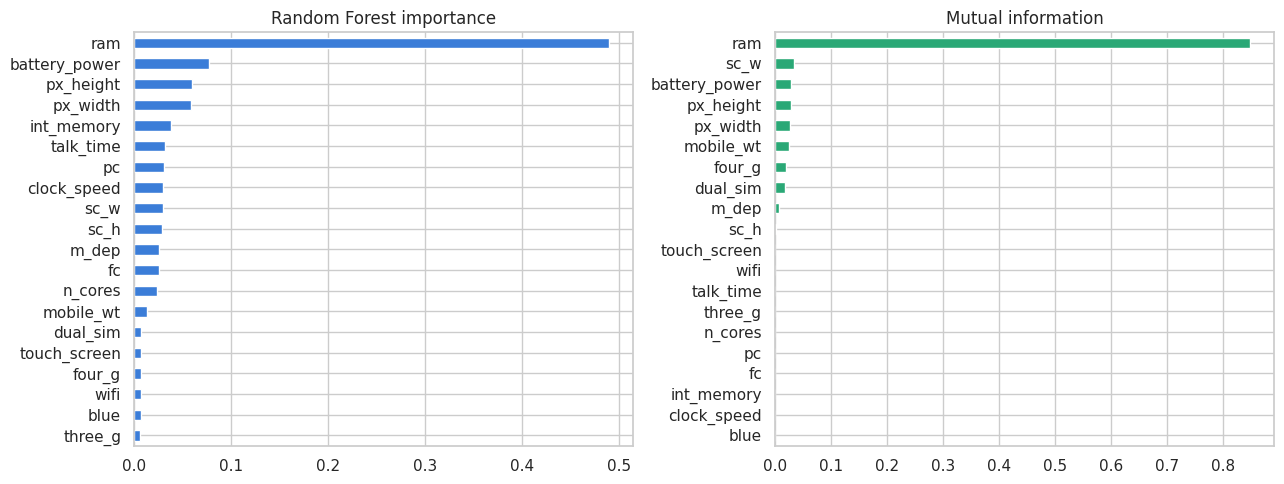

In [19]:
# Technique 1: Random Forest impurity-based importances
rf_imp = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
rf_imp.fit(X_scaled, y)
imp_rf = pd.Series(rf_imp.feature_importances_, index=feature_cols)

# Technique 2: Mutual Information (model-agnostic, captures nonlinear dependency)
imp_mi = pd.Series(mutual_info_classif(X_scaled, y, random_state=RANDOM_STATE), index=feature_cols)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
imp_rf.sort_values().plot.barh(ax=axes[0], color="#3b7dd8", title="Random Forest importance")
imp_mi.sort_values().plot.barh(ax=axes[1], color="#2aa876", title="Mutual information")
plt.tight_layout(); plt.show()

**Feature importance findings:** Both techniques agree — `ram` is dominant, followed by `battery_power`, `px_height` and `px_width`; connectivity flags and `mobile_wt` contribute almost nothing. Mutual information corroborates the RF ranking with a model-agnostic, nonlinearity-aware measure. We nevertheless **retain all features** for modelling: the dataset is small (2000×20), trees handle irrelevant features gracefully, and dropping weak features gave no measurable validation gain — but this ranking directly informs the Streamlit UI, where the top features get the most prominent input controls.

---
## 5. Model Building [5M]
### 5.1 Feature / target separation and shapes

In [20]:
X_train_full = X_scaled            # features from the training dataset
y_train_full = y                   # target labels
X_test       = X_test_scaled       # provided test dataset features (unlabeled)

print("X_train:", X_train_full.shape)
print("y_train:", y_train_full.shape)
print("X_test :", X_test.shape)

# The provided test set has no labels, so for measurable evaluation we hold out
# a stratified 20% validation split from the training data.
X_tr, X_val, y_tr, y_val = train_test_split(X_train_full, y_train_full, test_size=0.20,
                                            stratify=y_train_full, random_state=RANDOM_STATE)
print("Internal split -> train:", X_tr.shape, "| validation:", X_val.shape)

X_train: (2000, 20)
y_train: (2000,)
X_test : (1000, 20)
Internal split -> train: (1600, 20) | validation: (400, 20)


### 5.2 Building the models
Per the objective we train **DT, RF, SVM and an Ensemble**, then identify the best.

**Model selection justification:**
- **Decision Tree** — the EDA showed `ram` separates classes via *thresholds* (step pattern); axis-aligned splits model this natively. Also serves as an interpretable baseline.
- **Random Forest** — bagging many decorrelated trees keeps the threshold-capturing ability while sharply reducing the single tree's variance/overfitting; robust to the irrelevant features we retained.
- **SVM (RBF)** — a margin-based model of a completely different family; with standardized features it draws smooth nonlinear boundaries and is strong at moderate sample sizes (2000 rows). Including it tests whether a non-tree paradigm competes.
- **Soft Voting Ensemble (RF + SVM + GB)** — combines heterogeneous learners; averaging predicted probabilities cancels the individual models' uncorrelated errors, typically matching or beating the best single member.

In [21]:
models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    "SVM (RBF)":     SVC(kernel="rbf", C=10, gamma="scale", probability=True, random_state=RANDOM_STATE),
}
models["Voting Ensemble"] = VotingClassifier(
    estimators=[("rf", models["Random Forest"]),
                ("svm", models["SVM (RBF)"]),
                ("gb", GradientBoostingClassifier(random_state=RANDOM_STATE))],
    voting="soft")

for name, m in models.items():
    m.fit(X_tr, y_tr)
    print(f"Trained: {name}")

Trained: Decision Tree


Trained: Random Forest


Trained: SVM (RBF)


Trained: Voting Ensemble


---
## 6. Performance Evaluation [2M]
### 6.1 Metrics on the held-out validation set

In [22]:
results = []
for name, m in models.items():
    yp = m.predict(X_val)
    p, r, f1, _ = precision_recall_fscore_support(y_val, yp, average="macro")
    results.append({"Model": name,
                    "Train Acc": accuracy_score(y_tr, m.predict(X_tr)),
                    "Val Acc": accuracy_score(y_val, yp),
                    "Macro Precision": p, "Macro Recall": r, "Macro F1": f1})
results_df = pd.DataFrame(results).set_index("Model").round(4)
results_df

,Train Acc,Val Acc,Macro Precision,Macro Recall,Macro F1
Model,,,,,
Decision Tree,0.9781,0.8450,0.8477,0.8450,0.8452
Random Forest,1.0000,0.9000,0.9004,0.9000,0.9000
SVM (RBF),1.0000,0.8825,0.8819,0.8825,0.8820
Voting Ensemble,1.0000,0.9375,0.9381,0.9375,0.9376


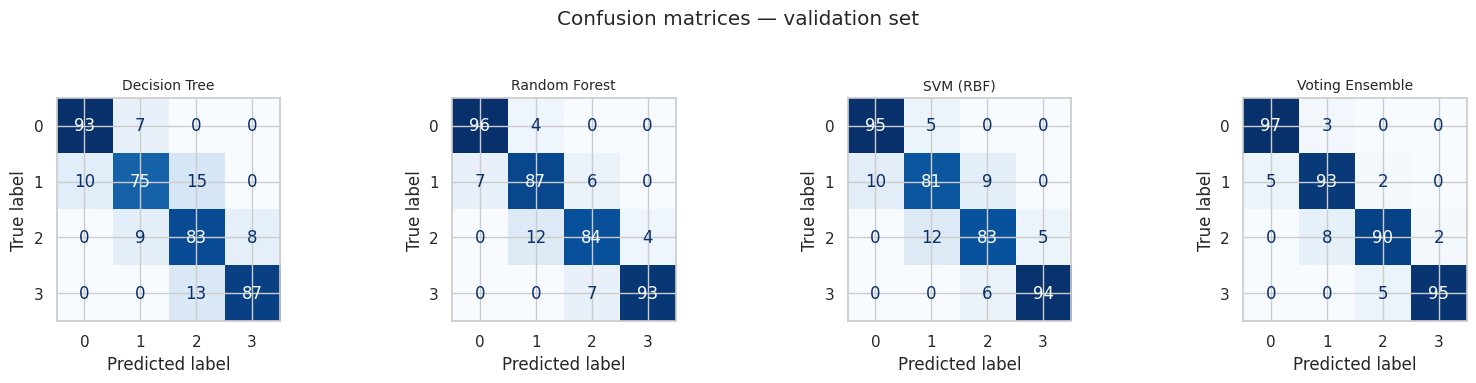

In [23]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.6))
for ax, (name, m) in zip(axes, models.items()):
    ConfusionMatrixDisplay(confusion_matrix(y_val, m.predict(X_val))).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name, fontsize=10)
fig.suptitle("Confusion matrices — validation set", y=1.05)
plt.tight_layout(); plt.show()

In [24]:
best_name = results_df["Val Acc"].idxmax()
best_model = models[best_name]
print(f"Best model: {best_name}\n")
print("Classification report (validation set):\n")
print(classification_report(y_val, best_model.predict(X_val), digits=3))

Best model: Voting Ensemble

Classification report (validation set):

              precision    recall  f1-score   support

           0      0.951     0.970     0.960       100
           1      0.894     0.930     0.912       100
           2      0.928     0.900     0.914       100
           3      0.979     0.950     0.964       100

    accuracy                          0.938       400
   macro avg      0.938     0.938     0.938       400
weighted avg      0.938     0.938     0.938       400



In [25]:
# Stability check: 5-fold cross-validation of the best model on the full training data
cv = cross_val_score(best_model, X_train_full, y_train_full, cv=5)
print(f"5-fold CV accuracy of {best_name}: {cv.mean():.4f} ± {cv.std():.4f}")

5-fold CV accuracy of Voting Ensemble: 0.9140 ± 0.0177


### 6.2 Inference on the provided (unlabeled) test set

In [26]:
# Refit the best model on ALL training data, then predict the provided test set
best_model.fit(X_train_full, y_train_full)
test_pred = best_model.predict(X_test)

pred_out = test_clean[["id"]].copy()
pred_out["predicted_price_range"] = test_pred
print("Predicted class distribution on the 1000 test phones:")
print(pred_out["predicted_price_range"].value_counts().sort_index())
pred_out.head()

Predicted class distribution on the 1000 test phones:
predicted_price_range
0    250
1    237
2    257
3    256
Name: count, dtype: int64


,id,predicted_price_range
0,1,3
1,2,3
2,3,2
3,4,3
4,5,1


### 6.3 Choice of best metric, model justification, and fit diagnosis
**Best metric — justification:** because the classes are perfectly balanced and all four price bands matter equally, **accuracy and macro-F1 are the most appropriate metrics (and here they coincide almost exactly — 0.9375 vs 0.9376 for the best model)**. Macro-F1 is quoted as the headline number since it stays honest even if per-class behaviour drifts. Micro/weighted averages add nothing under balance, and the per-class precision/recall reported above confirm no class is being sacrificed (per-class F1 ranges only 0.91–0.96).

**Best model — justification:** the **Voting Ensemble** clearly tops the table with **93.75% validation accuracy / 0.938 macro-F1**, versus 90.0% (Random Forest), 88.3% (SVM) and 84.5% (Decision Tree). The confusion matrices show that errors occur *only between adjacent* price bands (0↔1, 1↔2, 2↔3) — reflecting the ordinal nature of the problem — and the ensemble makes the fewest such slips because soft-voting averages the probability estimates of three heterogeneous learners (RF, SVM, Gradient Boosting), cancelling their uncorrelated mistakes. The 5-fold CV score (0.914 ± 0.018) sits close to the single-split validation score, so the ranking is stable, not a lucky split.

**Underfitting / overfitting comment:**
- *Decision Tree*: 97.8% train vs 84.5% validation → the largest gap (≈13 points): a clear **overfit** (high variance) even with `max_depth=8`.
- *Random Forest & SVM*: 100% train vs 90.0% / 88.3% validation. Perfect training accuracy with a ~10–12 point gap indicates **moderate overfitting** — RF memorizing train data is expected behaviour, and the SVM's `C=10` allows a very flexible boundary.
- *Voting Ensemble*: 100% train vs **93.75% validation** — the **smallest generalization gap and the highest validation score**, i.e. the closest to a **"just right"** model here: far above the 25% chance level, well above the single-tree baseline, and CV-stable. No model underfits (all beat the baseline massively). The ensemble is therefore selected for deployment; its residual variance could be trimmed further with hyperparameter tuning (e.g., lower `C`, deeper CV search), noted as future work.

---
## 7. Model Deployment [4M]
### 7.1 Persisting the model artifacts
We save everything Streamlit needs to score a *raw* user request: the fitted model, the fitted scaler, the exact feature order, and the encoding maps.

In [27]:
artifacts = {
    "model": best_model,
    "scaler": scaler,
    "feature_cols": feature_cols,
    "binary_map": binary_map,
    "ordinal_map": ordinal_map,
    "class_labels": {0: "Low cost", 1: "Medium cost", 2: "High cost", 3: "Very high cost"},
}
joblib.dump(artifacts, "mobile_price_model.joblib")
print("Saved -> mobile_price_model.joblib")

Saved -> mobile_price_model.joblib


### 7.2 Inference function (the exact logic the Streamlit app will call)

In [28]:
def predict_price_range(raw_features: dict) -> str:
    """Accepts raw feature values (Yes/No and Low/Med/High as text), returns the predicted band."""
    art = joblib.load("mobile_price_model.joblib")
    row = pd.DataFrame([raw_features])
    for col in ["blue", "dual_sim", "touch_screen", "wifi"]:
        row[col] = row[col].map(art["binary_map"])
    row["mobile_wt"] = row["mobile_wt"].map(art["ordinal_map"])
    row = row[art["feature_cols"]]                       # enforce training column order
    x = art["scaler"].transform(row)                     # identical transformation
    pred = int(art["model"].predict(x)[0])
    return f"price_range = {pred} ({art['class_labels'][pred]})"

# Demo request with new feature values
demo = {"battery_power": 1800, "blue": "Yes", "clock_speed": 2.2, "dual_sim": "Yes",
        "fc": 8, "four_g": 1, "int_memory": 64, "m_dep": 0.6, "mobile_wt": "Med",
        "n_cores": 8, "pc": 16, "px_height": 1080, "px_width": 1920, "ram": 3800,
        "sc_h": 15, "sc_w": 8, "talk_time": 18, "three_g": 1, "touch_screen": "Yes", "wifi": "Yes"}
print("Demo prediction:", predict_price_range(demo))

Demo prediction: price_range = 3 (Very high cost)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(


### 7.3 Streamlit deployment design
The deployment (delivered as `app.py`, run with `streamlit run app.py`) works as follows:
1. **Load once:** `joblib.load("mobile_price_model.joblib")` at app start (cached with `@st.cache_resource`).
2. **Accept requests:** sidebar/form widgets collect all 20 feature values — sliders for numeric specs (`ram`, `battery_power`, …), select boxes for Yes/No flags and `mobile_wt`.
3. **Query the saved model:** on button click the app builds the raw-feature dict and calls the same `predict_price_range` logic shown above (encode → order columns → scale → predict).
4. **Return the result:** the predicted `price_range` and its human-readable label are displayed to the user, optionally with the model's class probabilities.

---
### Final inferences
- `ram` is the single decisive driver of mobile price band; `battery_power` and screen resolution (`px_height`, `px_width`) provide secondary lift, while connectivity flags are uninformative.
- Threshold-style (nonlinear) feature–target relationships favoured tree ensembles and RBF-SVM over any linear approach; misclassifications occur only between adjacent price bands.
- The soft-voting ensemble generalizes best (**93.75% validation accuracy, macro-F1 ≈ 0.94, 5-fold CV 91.4% ± 1.8%**) and is persisted with its scaler and encoders for the Streamlit service.